In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataset=pd.read_csv("breast_cancer.csv")
dataset = dataset.drop('Sample code number', axis=1)
x=dataset.drop("Class", axis=1)
y=dataset["Class"]

In [4]:
print(dataset.isnull().sum())  

Clump Thickness                0
Uniformity of Cell Size        0
Uniformity of Cell Shape       0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Bland Chromatin                0
Normal Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64


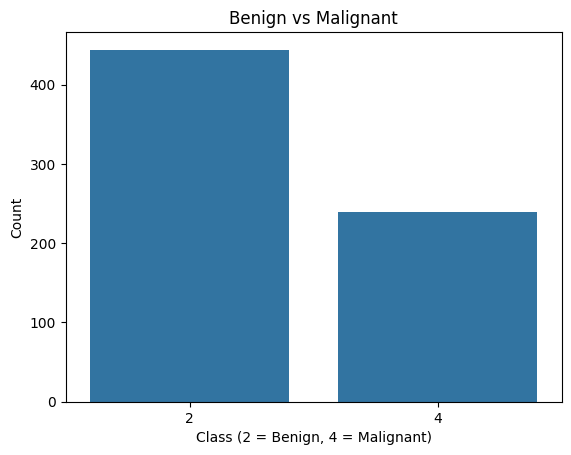

In [5]:
sns.countplot(x='Class',data=dataset)
plt.title("Benign vs Malignant")
plt.xlabel('Class (2 = Benign, 4 = Malignant)')
plt.ylabel('Count')
plt.show()

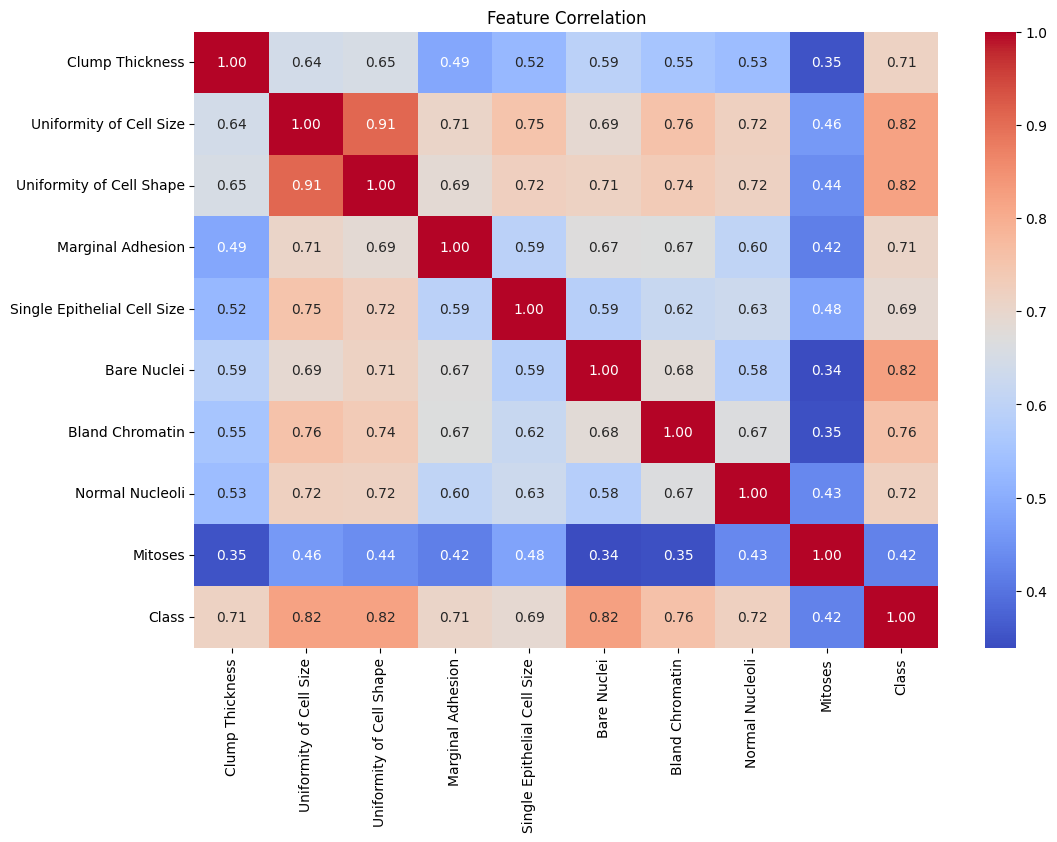

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(dataset.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

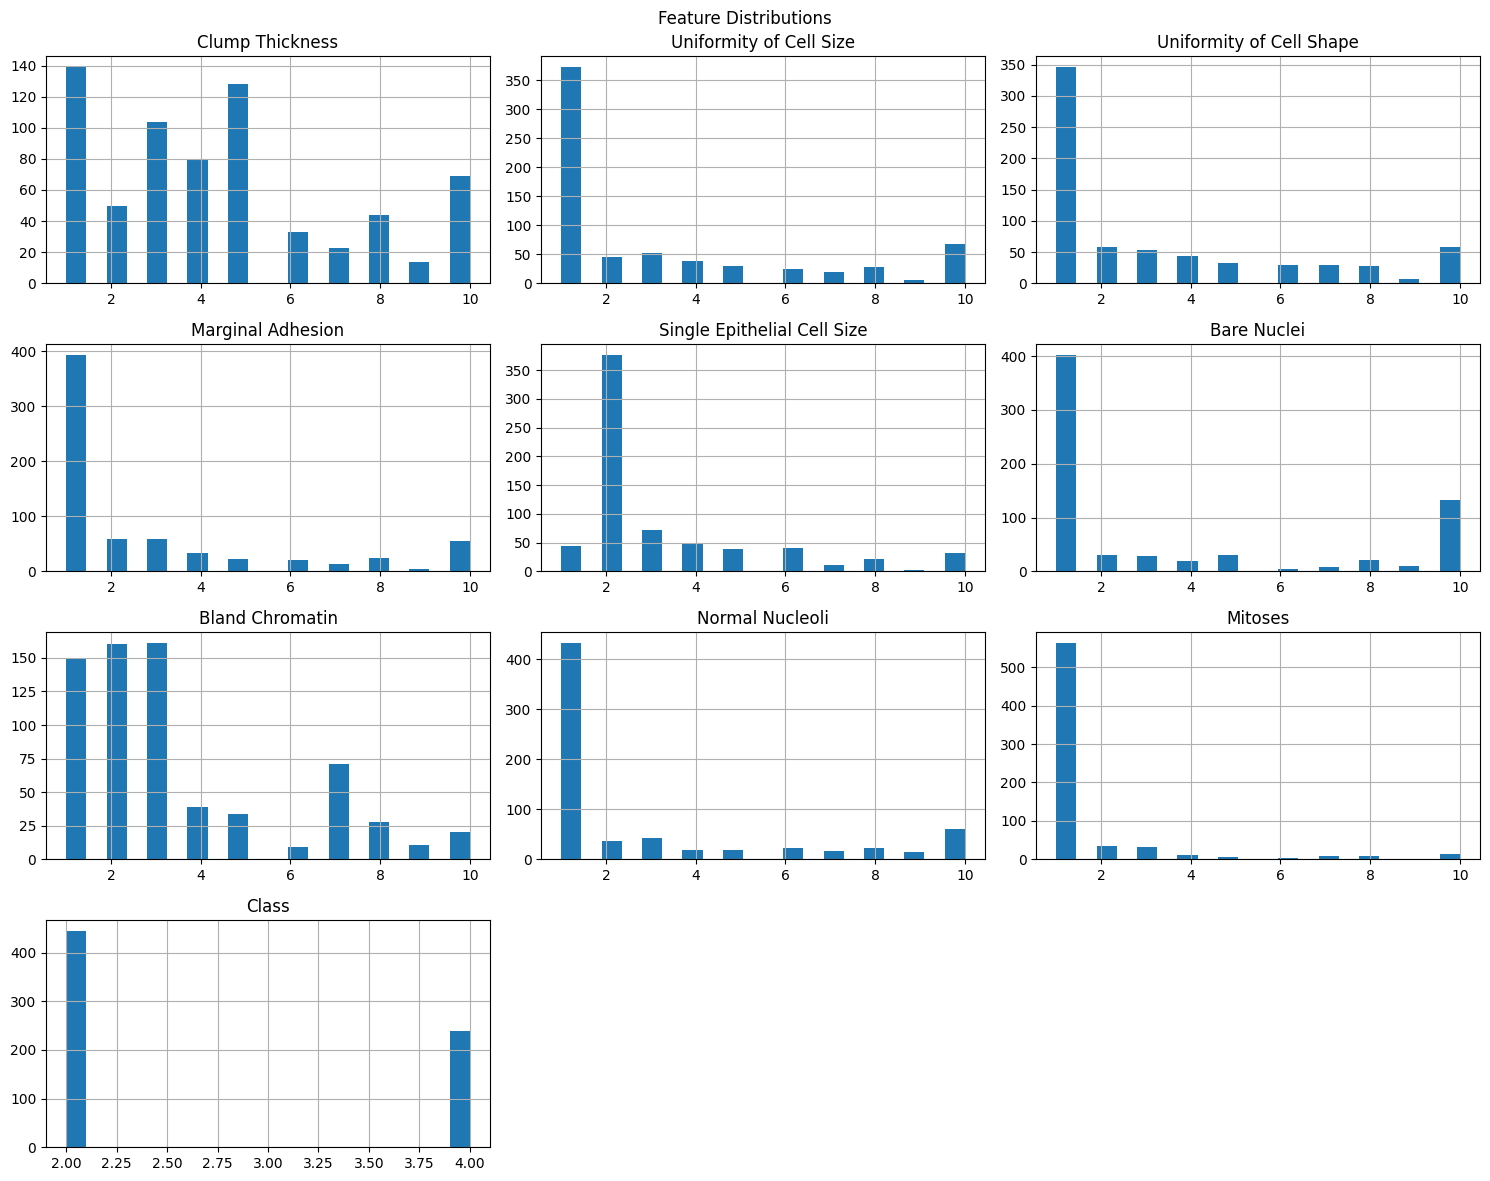

In [7]:
dataset.hist(figsize=(15,12), bins=20)
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

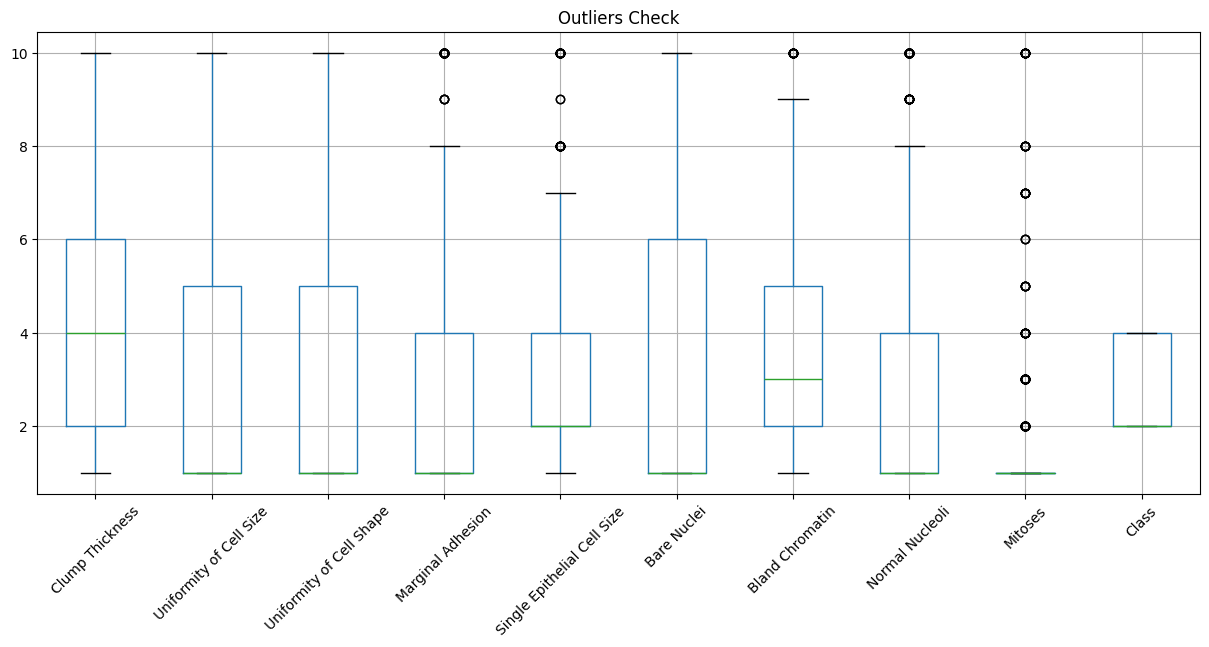

In [8]:
plt.figure(figsize=(15,6))
dataset.boxplot()
plt.title('Outliers Check')
plt.xticks(rotation=45)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
x_train ,x_test ,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=0)

In [10]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train = pd.DataFrame(sc.fit_transform(x_train), columns=x_train.columns)
x_test = pd.DataFrame( sc.transform(x_test), columns=x_test.columns)

In [11]:
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier(n_estimators=100, random_state=0)
classifier.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
y_pred_test=classifier.predict(x_test)
print(np.concatenate((y_pred_test.reshape(-1,1),y_test.values.reshape(-1,1)),1))

[[2 2]
 [2 2]
 [4 4]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [4 4]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [4 4]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [4 4]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [4 4]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [4 2]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [4 2]
 [4 4]
 [2 2]
 [4 4]
 [2 2]
 [4 4]
 [4 4]
 [4 4]
 [4 2]
 [4 4]
 [4 4]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [4 4]
 [2 2]
 [2 2]
 [4 4]
 [2 4]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [4 4]
 [4 4]
 [2 2]
 [4 4]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [4 4]
 [2 2]
 [2 2]
 [4 4]
 [2 2]]


Accuracy is: 0.9708029197080292
F1 Score: 0.96
              precision    recall  f1-score   support

           2       0.99      0.97      0.98        87
           4       0.94      0.98      0.96        50

    accuracy                           0.97       137
   macro avg       0.97      0.97      0.97       137
weighted avg       0.97      0.97      0.97       137



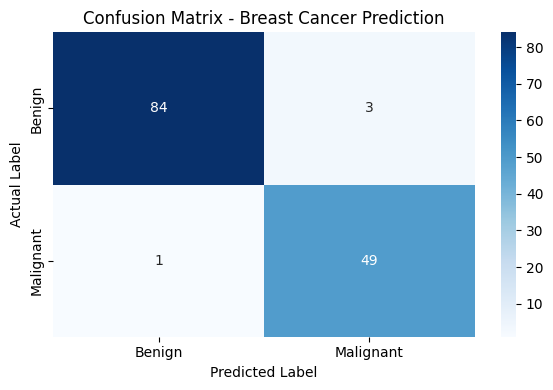

In [13]:
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score,classification_report
matrix=confusion_matrix(y_test,y_pred_test)
acc_score=accuracy_score(y_test,y_pred_test,normalize=True)
print("Accuracy is:",acc_score)
f1 = f1_score(y_test, y_pred_test,pos_label=4)
print(f"F1 Score: {f1:.2f}")
print(classification_report(y_test, y_pred_test))

plt.figure(figsize=(6,4))
sns.heatmap(matrix, 
            annot=True,        
            fmt='d',           
            cmap='Blues',      
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix - Breast Cancer Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.model_selection import cross_val_score
accuracies=cross_val_score(estimator=classifier, X=x_train ,y=y_train,cv=10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 96.70 %
Standard Deviation: 2.58 %


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
    "SVM": SVC(random_state=0),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=0)
}

results = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = round(acc * 100, 2)
    print(f"{name}: {acc*100:.2f}%")

Logistic Regression: 95.62%
Random Forest: 97.08%
SVM: 95.62%
KNN: 95.62%
Decision Tree: 94.16%


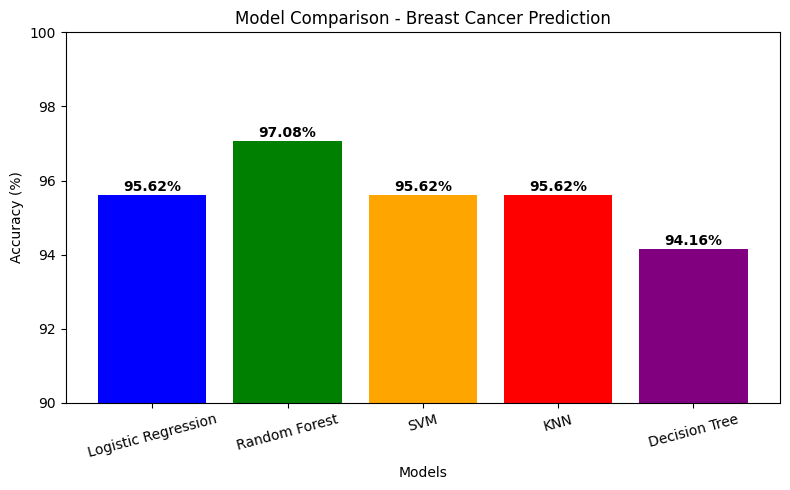

In [16]:
plt.figure(figsize=(8,5))
colors = ['blue', 'green', 'orange', 'red', 'purple']
plt.bar(results.keys(), results.values(), color=colors)
plt.title('Model Comparison - Breast Cancer Prediction')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.ylim([90, 100])
plt.xticks(rotation=15)
for i, (model, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.1, f"{acc}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
new_data = pd.DataFrame([{
   'Clump Thickness':5, 
   'Uniformity of Cell Size':1,
   'Uniformity of Cell Shape':1,
   'Marginal Adhesion':1,
   'Single Epithelial Cell Size':2,
   'Bare Nuclei':1,
   'Bland Chromatin':3,
   'Normal Nucleoli':1,
   'Mitoses':1
}])

new_data = new_data[x_train.columns]

transform_data = pd.DataFrame(sc.transform(new_data), columns=x_train.columns)

prediction = classifier.predict(transform_data)

print("Predicted breast cancer is:", prediction[0])

Predicted breast cancer is: 2


In [23]:
min_vals = sc.inverse_transform([x_train.min()])
max_vals = sc.inverse_transform([x_train.max()])
pd.DataFrame({
    "min": min_vals[0],
    "max": max_vals[0]
}, index=x_train.columns)

,min,max
Clump Thickness,1.0,10.0
Uniformity of Cell Size,1.0,10.0
Uniformity of Cell Shape,1.0,10.0
Marginal Adhesion,1.0,10.0
Single Epithelial Cell Size,1.0,10.0
Bare Nuclei,1.0,10.0
Bland Chromatin,1.0,10.0
Normal Nucleoli,1.0,10.0
Mitoses,1.0,10.0


In [18]:
import pickle
pickle.dump(classifier, open('model.pkl', 'wb'))
pickle.dump(sc, open('scaler.pkl', 'wb'))
print("Model saved!")

Model saved!
